### Abou the Project
This project builds several different models to predict whether a patient has breast cancer or not based on the following features:

- diagnosis: (label) the diagnosis of breast (label) tissues (M = malignant, B = benign).
- radius: distances from center to points on the perimeter.
- texture: standard deviation of gray-scale values.
- perimeter: perimeter of the tumor.
- area: area of the tumor.
- smoothness: local variation in radius lengths.
- compactness: is equal to (perimeter^2 / area - 1.0).
- concavity: severity of concave portions of the contour.
- concave points: number of concave portions of the contour.
- symmetry: symmetry of the tumor shape.
- fractal dimension: "coastline approximation" - 1.

Then, it aims to compare the performance of each model on the test set.



In [1]:
# Load the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.naive_bayes import GaussianNB



In [ ]:
# Load the dataset
df = pd.read_csv("data-breast-cancer.csv")
# Some data samples
df.head()

In [ ]:
print(df.info(),
    df.describe(include="object"),
    df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Unnamed: 0              569 non-null    int64  
 1   diagnosis               569 non-null    object 
 2   radius_mean             569 non-null    float64
 3   texture_mean            569 non-null    float64
 4   perimeter_mean          569 non-null    float64
 5   area_mean               569 non-null    float64
 6   smoothness_mean         569 non-null    float64
 7   compactness_mean        569 non-null    float64
 8   concavity_mean          569 non-null    float64
 9   concave points_mean     569 non-null    float64
 10  symmetry_mean           569 non-null    float64
 11  fractal_dimension_mean  569 non-null    float64
dtypes: float64(10), int64(1), object(1)
memory usage: 53.5+ KB
None        diagnosis
count        569
unique         2
top            B
freq         357

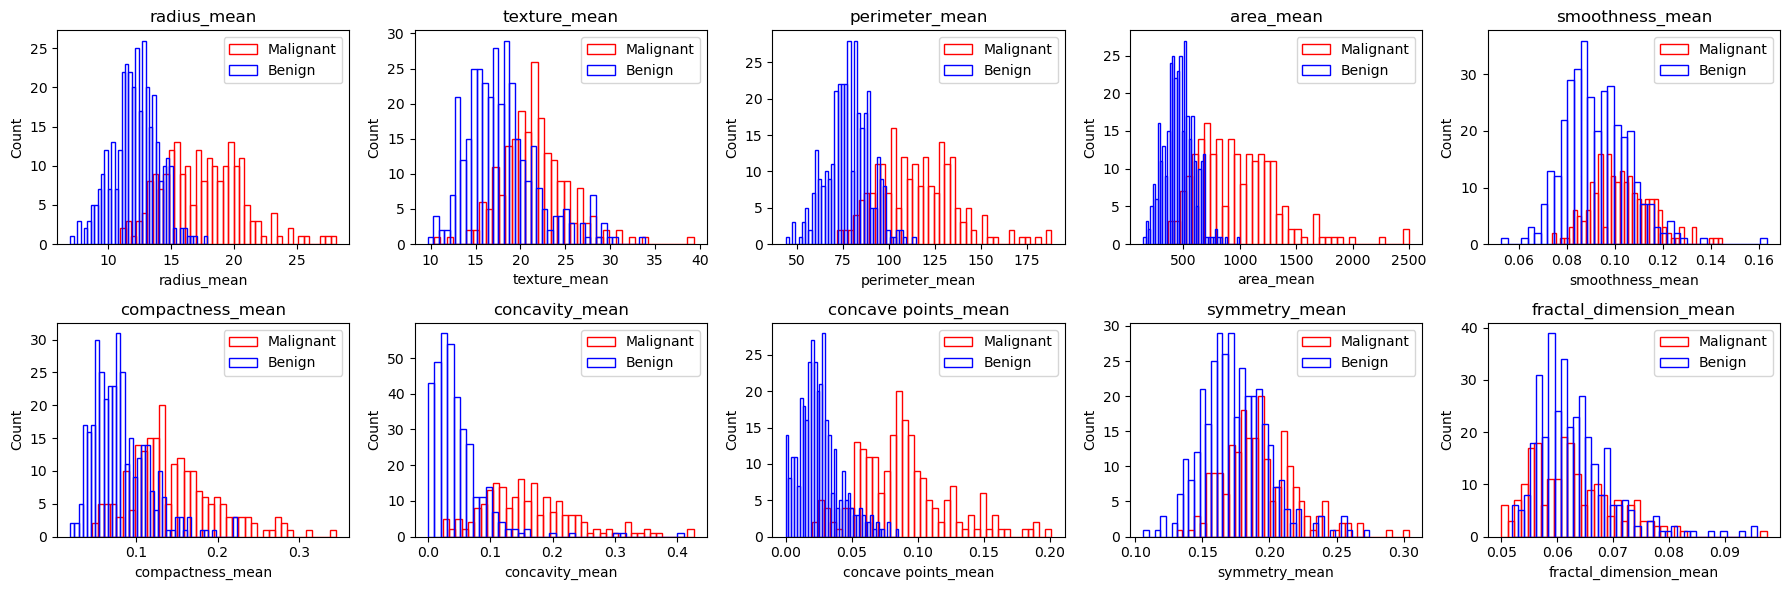

In [ ]:
df = df.drop(columns = ["Unnamed: 0"])
features = [feature for feature in df.columns if feature != "diagnosis"]
n_features = len(features)
cols = 5
rows = (n_features + cols - 1) // cols  

plt.figure(figsize=(18, rows * 3))

for i, feature in enumerate(features, 1):
    plt.subplot(rows, cols, i)
    
    plt.hist(df[df["diagnosis"] == "M"][feature], bins=40, facecolor='none', edgecolor='red', label='Malignant')
    plt.hist(df[df["diagnosis"] == "B"][feature], bins=40, facecolor='none', edgecolor='blue', label='Benign')
    
    plt.xlabel(feature)
    plt.ylabel("Count")
    plt.title(feature)
    plt.legend()

plt.tight_layout()
plt.show()

'''
There are noticeable differences in the distribution of tumor most features between the malignant and the benign group, with the exception of smoothness_mean.
The most drastic differences are between the perimeter, concave points, and area of beign tumors compared to malignant ones, where these distributions of 
benign tumors sharply skews left and have smaller range compared to the distributions of such features of malignant tumors which are smoother and have larger 
variation.
'''


In [ ]:
data = df.copy()

X = data[features]
y = data["diagnosis"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=15)
#bool_mask = np.logical_and.reduce([X_train[feature] <= X_train[feature].quantile(0.98) for feature in X_train.columns])
#X_train = X_train[bool_mask]
#y_train = y_train[bool_mask]
# I initially removed outliers before training, however when I trained again with the outliers in tact, the metrics are almost higher across the board
# I hypothesize that: 1. the outliers are features of the data and is not due to human errors, 2. even though SVMs are sensitive to outliers, the outliers
# in this dataset is not too extreme that it deteriorates the performance of the model

normalizer = StandardScaler()
X_train = normalizer.fit_transform(X_train)
X_test = normalizer.transform(X_test)


In [31]:
hyperparams = {
    "gamma": ['scale', 'auto'] + list(np.logspace(-3, -1, 10)),
    "kernel": ['linear', 'poly', 'rbf', 'sigmoid'],
    "C": np.logspace(-2, 3, 10)
}
gridsearch_svc = GridSearchCV(SVC(), hyperparams, cv=10, return_train_score=True, scoring='f1_weighted')
gridsearch_svc.fit(X_train, y_train)


,estimator,SVC()
,param_grid,"{'C': array([1.0000...00000000e+03]), 'gamma': ['scale', 'auto', ...], 'kernel': ['linear', 'poly', ...]}"
,scoring,'f1_weighted'
,n_jobs,None
,refit,True
,cv,10
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,C,np.float64(1000.0)


In [32]:
print(gridsearch_svc.best_params_,
      gridsearch_svc.best_score_)

{'C': np.float64(1000.0), 'gamma': np.float64(0.004641588833612777), 'kernel': 'rbf'} 0.9623717824903544


In [ ]:
'''
Some comments on underfitting and overfitting: there were cases of underfitting where the model didnt fit 
well the data it was trained on and the testing data. It can be seen by both low train score and test score 
in the csv below. This underfitting occurred for cases where gamma and C are both low or either gamma or C 
was low. No severe cases of overfitting was observed.
'''
cv_results = gridsearch_svc.cv_results_
cv_results.keys()
results_df = pd.DataFrame(cv_results)[["param_kernel", "param_C", "param_gamma", "mean_train_score", "mean_test_score"]]
results_df
#results_df.to_csv("gridsearch_res_svc.csv", index=False)

In [33]:
svm_model = gridsearch_svc.best_estimator_
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)
print(classification_report(y_test, y_pred_svm))


              precision    recall  f1-score   support

           B       0.92      0.97      0.95        75
           M       0.94      0.85      0.89        39

    accuracy                           0.93       114
   macro avg       0.93      0.91      0.92       114
weighted avg       0.93      0.93      0.93       114



In [ ]:
# *NAIVE BAYES
hyperparams = {
    "var_smoothing": [0] + list(np.logspace(-9, -5, 20)),
    "priors": [None] + [[p, 1-p] for p in np.linspace(0.1, 0.9, 20)]
}

gridsearch_nb = GridSearchCV(GaussianNB(), hyperparams, cv=10, scoring="f1_weighted")
gridsearch_nb.fit(X_train, y_train)


,estimator,GaussianNB()
,param_grid,"{'priors': [None, [np.float64(0.1), np.float64(0.9)], ...], 'var_smoothing': [0, np.float64(1e-09), ...]}"
,scoring,'f1_weighted'
,n_jobs,None
,refit,True
,cv,10
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,priors,"[np.float64(0....2631578947365), np.float64(0.6894736842105263)]"


In [11]:
print(gridsearch_nb.best_params_, gridsearch_nb.best_score_)

{'priors': [np.float64(0.31052631578947365), np.float64(0.6894736842105263)], 'var_smoothing': 0} 0.9294503514264012


In [12]:
nb_model = gridsearch_nb.best_estimator_
nb_model.fit(X_train, y_train)
y_pred_nb = nb_model.predict(X_test)
print(classification_report(y_test, y_pred_nb))

              precision    recall  f1-score   support

           B       0.91      0.95      0.93        75
           M       0.89      0.82      0.85        39

    accuracy                           0.90       114
   macro avg       0.90      0.88      0.89       114
weighted avg       0.90      0.90      0.90       114



In [ ]:
hyperparams = {
    "criterion": ["gini", "entropy"],
    "max_depth": list(range(2, 6)),
    "min_samples_split": list(range(2, 8))

}

gridsearch_dt = GridSearchCV(DecisionTreeClassifier(), hyperparams, scoring="f1_weighted", cv=10)
gridsearch_dt.fit(X_train, y_train)

,estimator,DecisionTreeClassifier()
,param_grid,"{'criterion': ['gini', 'entropy'], 'max_depth': [2, 3, ...], 'min_samples_split': [2, 3, ...]}"
,scoring,'f1_weighted'
,n_jobs,None
,refit,True
,cv,10
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [14]:
print(gridsearch_dt.best_params_, gridsearch_dt.best_score_)

{'criterion': 'gini', 'max_depth': 2, 'min_samples_split': 2} 0.9474926224194288


In [15]:
dt_model = gridsearch_dt.best_estimator_
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           B       0.94      0.91      0.93        75
           M       0.83      0.90      0.86        39

    accuracy                           0.90       114
   macro avg       0.89      0.90      0.89       114
weighted avg       0.91      0.90      0.90       114



In [ ]:
hyperparams = {
    'criterion': ['gini', 'entropy'],
    'n_estimators': [100],
    'max_depth': [None, 12, 16, 20],
    'min_samples_split': [4, 6, 8],
    'min_samples_leaf': [4, 6, 8],
    'max_features': [None, 'sqrt', 'log2'],
    'n_jobs': [-1]
}

gridsearch_rf = GridSearchCV(RandomForestClassifier(), hyperparams, scoring="f1_weighted", cv=5) 
gridsearch_rf.fit(X_train, y_train)

,estimator,RandomForestClassifier()
,param_grid,"{'criterion': ['gini', 'entropy'], 'max_depth': [None, 12, ...], 'max_features': [None, 'sqrt', ...], 'min_samples_leaf': [4, 6, ...], ...}"
,scoring,'f1_weighted'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [17]:
print(gridsearch_rf.best_params_, gridsearch_rf.best_score_)

{'criterion': 'gini', 'max_depth': 16, 'max_features': 'log2', 'min_samples_leaf': 6, 'min_samples_split': 4, 'n_estimators': 100, 'n_jobs': -1} 0.9450835697253275


In [18]:
rf_model = gridsearch_rf.best_estimator_
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           B       0.92      0.95      0.93        75
           M       0.89      0.85      0.87        39

    accuracy                           0.91       114
   macro avg       0.91      0.90      0.90       114
weighted avg       0.91      0.91      0.91       114



In [ ]:
# *LOGISTIC REGRESSION
hyperparams = {
    'solver': ['liblinear', 'lbfgs'], 
    'penalty': ['l2'],                 
    'C': list(np.logspace(-3, 3, 7)),
    'max_iter': [5000]                 
}
gridsearch_lr = GridSearchCV(LogisticRegression(), hyperparams, scoring="f1_weighted", cv=10)
gridsearch_lr.fit(X_test, y_test)



,estimator,LogisticRegression()
,param_grid,"{'C': [np.float64(0.001), np.float64(0.01), ...], 'max_iter': [5000], 'penalty': ['l2'], 'solver': ['liblinear', 'lbfgs']}"
,scoring,'f1_weighted'
,n_jobs,None
,refit,True
,cv,10
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [20]:
print(gridsearch_lr.best_params_, gridsearch_lr.best_score_)

{'C': np.float64(1.0), 'max_iter': 5000, 'penalty': 'l2', 'solver': 'liblinear'} 0.9090483209600858


In [21]:
lr_model = gridsearch_lr.best_estimator_
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           B       0.91      0.95      0.93        75
           M       0.89      0.82      0.85        39

    accuracy                           0.90       114
   macro avg       0.90      0.88      0.89       114
weighted avg       0.90      0.90      0.90       114



In [22]:
# Your code goes here. Please make sure to explain the reasons behind your data processing and modeling choices.
# 1.4
# *BAGGING
bagging_svc = BaggingClassifier(estimator=gridsearch_svc.best_estimator_, n_estimators=1000, max_samples=0.5)
bagging_svc.fit(X_train, y_train)
y_pred_bagging = bagging_svc.predict(X_test)
print(classification_report(y_test, y_pred_bagging))


              precision    recall  f1-score   support

           B       0.93      0.95      0.94        75
           M       0.89      0.87      0.88        39

    accuracy                           0.92       114
   macro avg       0.91      0.91      0.91       114
weighted avg       0.92      0.92      0.92       114



In [23]:
# 1.4
# *BOOSTING
ada_model = AdaBoostClassifier(estimator=gridsearch_dt.best_estimator_, n_estimators=2000)

ada_model.fit(X_train, y_train)
y_pred_ada = ada_model.predict(X_test)
print(classification_report(y_test, y_pred_ada))


              precision    recall  f1-score   support

           B       0.95      0.96      0.95        75
           M       0.92      0.90      0.91        39

    accuracy                           0.94       114
   macro avg       0.93      0.93      0.93       114
weighted avg       0.94      0.94      0.94       114



In [24]:
y_train_xgb = pd.get_dummies(y_train)
y_test_xgb = pd.get_dummies(y_test)
xgb_model = XGBClassifier(estimator=gridsearch_dt.best_estimator_, n_estimators=500)
xgb_model.fit(X_train, y_train_xgb)
y_pred_xgb = xgb_model.predict(X_test)
print(classification_report(y_test_xgb, y_pred_xgb))

/home/hoangpham219/miniconda3/envs/machine_learning/lib/python3.14/site-packages/xgboost/training.py:199: UserWarning: [00:47:00] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1762060489429/work/src/learner.cc:790: 
Parameters: { "estimator" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

           0       0.94      0.97      0.95        75
           1       0.94      0.87      0.91        39

   micro avg       0.94      0.94      0.94       114
   macro avg       0.94      0.92      0.93       114
weighted avg       0.94      0.94      0.94       114
 samples avg       0.94      0.94      0.94       114



In [25]:
# 1.4
# *STACKING
# *VotingClassifier
estimators = [("svm", gridsearch_svc.best_estimator_), 
              ("nb", gridsearch_nb.best_estimator_),
              ("rf", gridsearch_rf.best_estimator_),
              ("lg", gridsearch_lr.best_estimator_)
              ]
voting_model = VotingClassifier(estimators, voting="hard", n_jobs=-1)
voting_model.fit(X_train, y_train)
y_pred_voting = voting_model.predict(X_test)
print(f"Metrics for Voting:\n{classification_report(y_test, y_pred_voting)}")

# *StackingClassifier
stacking_model = StackingClassifier(estimators, n_jobs=-1)
stacking_model.fit(X_train, y_train)
y_pred_stacking = voting_model.predict(X_test)
print(f"Metrics for Stacking:\n{classification_report(y_test, y_pred_stacking)}")

Metrics for Voting:
              precision    recall  f1-score   support

           B       0.91      0.97      0.94        75
           M       0.94      0.82      0.88        39

    accuracy                           0.92       114
   macro avg       0.93      0.90      0.91       114
weighted avg       0.92      0.92      0.92       114

Metrics for Stacking:
              precision    recall  f1-score   support

           B       0.91      0.97      0.94        75
           M       0.94      0.82      0.88        39

    accuracy                           0.92       114
   macro avg       0.93      0.90      0.91       114
weighted avg       0.92      0.92      0.92       114



In [ ]:
'''
The SVM model generally performed better than other models, which even includes bagging and stacking ensembles. It was only edged out by boosting ensemble models: XGBoost and AdaBoost
'''